<a href="https://colab.research.google.com/github/amatsukami0420/AI_Lab_Assignments-CSC262/blob/main/Lab_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NAME:** Muhammad Waleed Bin Anwar
# **REG NO:** FA24-BCS-110
# **SECTION:** 4C
[github link](https://github.com/amatsukami0420/AI_Lab_Assignments-CSC262)

# TASK 1:

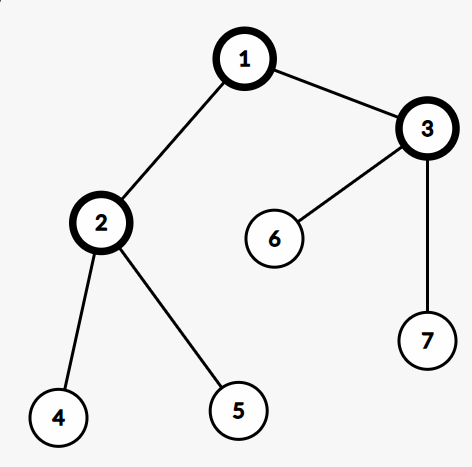

BFS and DFS applied to the above tree

In [1]:
from collections import deque

In [3]:
graph_data = """
1 2
1 3
2 4
2 5
3 6
3 7
"""

In [9]:
def build_graph(data):
    adj = {}
    for line in data.strip().split("\n"):
      u, v = line.split()
      if u not in adj: adj[u] = []
      if v not in adj: adj[v] = []
      adj[u].append(v)
      adj[v].append(u)
    return adj

In [6]:
def bfs(graph, start):
  visited = []
  queue = deque([start])
  while queue:
    node = queue.popleft()
    if node not in visited:
      visited.append(node)
      queue.extend(n for n in graph[node] if n not in visited)
  return visited

In [7]:
def dfs(graph, start):
  visited = []
  stack = [start]
  while stack:
    node = stack.pop()
    if node not in visited:
      visited.append(node)
      stack.extend(n for n in graph[node] if n not in visited)
  return visited

In [11]:
my_graph = build_graph(graph_data)
print(f"BFS Traversal: {bfs(my_graph, '1')}")
print(f"DFS Traversal: {dfs(my_graph, '1')}")

BFS Traversal: ['1', '2', '3', '4', '5', '6', '7']
DFS Traversal: ['1', '3', '7', '6', '2', '5', '4']


# TASK 2:


1. Generate random and unique numbers of ranges 1000,40,000,80,000,200,000 and
1,000,000. So now you have 5 sets of inputs, build the tree for each sets (each set has its
own list)
2. Apply BFS and DFS on each sets and calculate the time taken for the execution to find
that goal through BFS and DFS.
3. Goal should be lis[total_len – 220]
4. Make a data frame for your results as shown below.
5. Finally plot the bar chart of the time taken by each search for example (on X-axis the data
will be 1000,40,000,80,000,200,000 and 1,000,000.) and on the Y axis the data will be
the seconds it took while searching.

In [20]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

def run_performance_test():
  sizes = [1000, 40000, 80000, 200000, 1000000]
  results = []
  for size in sizes:
    data = random.sample(range(size*10), size)
    goal = data[size - 220]

    start_time = time.time()
    queue = deque([0])
    while queue:
      idx = queue.popleft()
      if idx < size:
        if data[idx] == goal: break
        queue.append(2*idx+1)
        queue.append(2*idx+2)
    bfs_time = time.time() - start_time
    stack = [0]
    while stack:
      idx = stack.pop()
      if idx < size:
        if data[idx] == goal: break
        stack.append(2*idx+2)
        stack.append(2*idx+1)
    dfs_time = time.time() - start_time

    results.append({"Tree Size": size, "BFS Time": bfs_time, "DFS Time": dfs_time})

  df = pd.DataFrame(results)
  print(df.to_string(index=False))

  df.plot(x="Tree Size", y=["BFS Time", "DFS Time"], kind="bar")
  plt.title("Search Time Comparison")
  plt.ylabel("Seconds")
  plt.show()

 Tree Size  BFS Time  DFS Time
      1000  0.000186  0.000324
     40000  0.009564  0.012947
     80000  0.022529  0.029809
    200000  0.066570  0.110508
   1000000  0.268619  0.508876


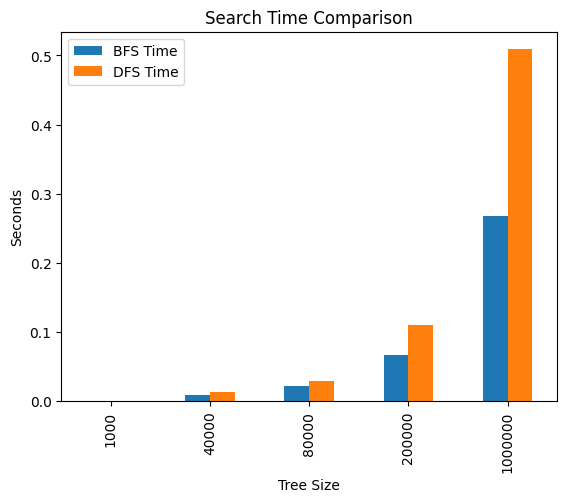

In [21]:
run_performance_test()

# TASK 3:


Imagine you're a tourist in Pakistan, and you want to travel from Islamabad to Karachi. You
want to find the shortest route in terms of the number of cities you need to travel through. The
cities are connected through highways, and your goal is to find the shortest path using BFS.

**Cities and Their Connections (Graph):**

You will use the following cities and their connections for this scenario:
* Islamabad is connected to Rawalpindi, Lahore, and Peshawar.
* Rawalpindi is connected to Islamabad, Peshawar, and Quetta.
* Peshawar is connected to Islamabad, Rawalpindi, and Quetta.
* Lahore is connected to Islamabad, Multan, and Quetta.
* Multan is connected to Lahore, Karachi, and Quetta.
* Quetta is connected to Rawalpindi, Peshawar, Multan, and Karachi.
* Karachi is connected to Multan and Quetta.

In [23]:
pak_cities = {
    'Islamabad': ['Rawalpindi', 'Lahore', 'Peshawar'],
    'Rawalpindi': ['Islamabad', 'Peshawar', 'Quetta'],
    'Peshawar': ['Islamabad', 'Rawalpindi', 'Quetta'],
    'Lahore': ['Islamabad', 'Multan', 'Quetta'],
    'Multan': ['Lahore', 'Karachi', 'Quetta'],
    'Quetta': ['Rawalpindi', 'Peshawar', 'Multan', 'Karachi'],
    'Karachi': ['Multan', 'Quetta']
}

In [25]:
def find_shortest_route(graph, start, end):
  queue = deque([[start]])
  visited = {start}
  while queue:
    path = queue.popleft()
    city = path[-1]
    if city == end:
      return path

    for neighbour in graph.get(city, []):
      if neighbour not in visited:
        visited.add(neighbour)
        new_path = list(path)
        new_path.append(neighbour)
        queue.append(new_path)
  return None

In [26]:
route = find_shortest_route(pak_cities, 'Islamabad', 'Karachi')
print(f"Shortest Route: {' -> '.join(route)}")

Shortest Route: Islamabad -> Rawalpindi -> Quetta -> Karachi
